## Visualisation of all mammary cancer data 
 


In [ ]:
# going to try and use as much of the TISMO data as possible 

In [17]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt

In [18]:

df = pd.read_csv("Mammary_data_response_1e8.csv")
df

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
0,SRX3453162,0.000000,0.000879,0.000000,0.000000,isotype,NaN,NaN,Baseline,GSM2879407,EMT6,Mammary carcinoma,GSE107801
1,SRX3453163,0.002060,0.000940,0.000000,0.000406,isotype,NaN,NaN,Baseline,GSM2879408,EMT6,Mammary carcinoma,GSE107801
2,SRX3453164,0.001590,0.000739,0.000000,0.000352,isotype,NaN,NaN,Baseline,GSM2879409,EMT6,Mammary carcinoma,GSE107801
3,SRX3453165,0.000880,0.000558,0.000000,0.000304,isotype,NaN,NaN,Baseline,GSM2879410,EMT6,Mammary carcinoma,GSE107801
4,SRX3453166,0.001856,0.000691,0.000000,0.000313,isotype,NaN,NaN,Baseline,GSM2879411,EMT6,Mammary carcinoma,GSE107801
...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,SRX10815545,0.002316,0.001167,0.000080,0.000349,antiPD1; high.fat.diet;,high.fat.diet,NaN,NR,GSM5285286,E0771,Mammary adenocarcinoma,GSE174053
609,SRX10815546,0.003241,0.001130,0.000013,0.000332,antiPD1; high.fat.diet;,high.fat.diet,NaN,NR,GSM5285287,E0771,Mammary adenocarcinoma,GSE174053
610,SRX10815547,0.002287,0.000956,0.000098,0.000341,antiPD1; high.fat.diet;,high.fat.diet,NaN,NR,GSM5285288,E0771,Mammary adenocarcinoma,GSE174053
611,SRX10815548,0.003830,0.001049,0.000000,0.000259,isotype; high.fat.diet;,high.fat.diet,NaN,Baseline,GSM5285289,E0771,Mammary adenocarcinoma,GSE174053


In [5]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


## Looking at the T11 x KPB25L immunotherapy vs no immunotherapy data 

In [35]:
# Load data
df = pd.read_csv("Mammary_data_response_1e8.csv")
df_time = df[df['Cell_Line'].isin(['T11', 'KPB25L'])]

df_time

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
48,SRX5100689,0.002064,0.000734,0.000382,0.000513,antiPD1; antiCTLA4;,day7,day7,R,GSM3554691,KPB25L,"Mammary cancer, NOS",GSE124821
49,SRX5100686,0.003045,0.001085,0.000000,0.000323,no_treatment,day7,day7,Baseline,GSM3554692,KPB25L,"Mammary cancer, NOS",GSE124821
50,SRX5100687,0.003010,0.001099,0.000035,0.000405,no_treatment,day7,day7,Baseline,GSM3554693,KPB25L,"Mammary cancer, NOS",GSE124821
51,SRX5100692,0.003047,0.001047,0.000033,0.000403,no_treatment,day7,day7,Baseline,GSM3554694,KPB25L,"Mammary cancer, NOS",GSE124821
52,SRX5100693,0.003165,0.000861,0.000000,0.000336,no_treatment,day7,day7,Baseline,GSM3554695,KPB25L,"Mammary cancer, NOS",GSE124821
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,SRX5100807,0.003208,0.001269,0.000000,0.000442,antiPD1; antiCTLA4;,end,end,NR,GSM3554932,T11,"Mammary cancer, NOS",GSE124821
236,SRX5100814,0.002745,0.001124,0.000000,0.000464,antiPD1; antiCTLA4;,end,end,NR,GSM3554933,T11,"Mammary cancer, NOS",GSE124821
237,SRX5100813,0.002178,0.000910,0.000000,0.000339,no_treatment,end,end,Baseline,GSM3554934,T11,"Mammary cancer, NOS",GSE124821
238,SRX5100812,0.002956,0.001310,0.000041,0.000505,no_treatment,end,end,Baseline,GSM3554935,T11,"Mammary cancer, NOS",GSE124821


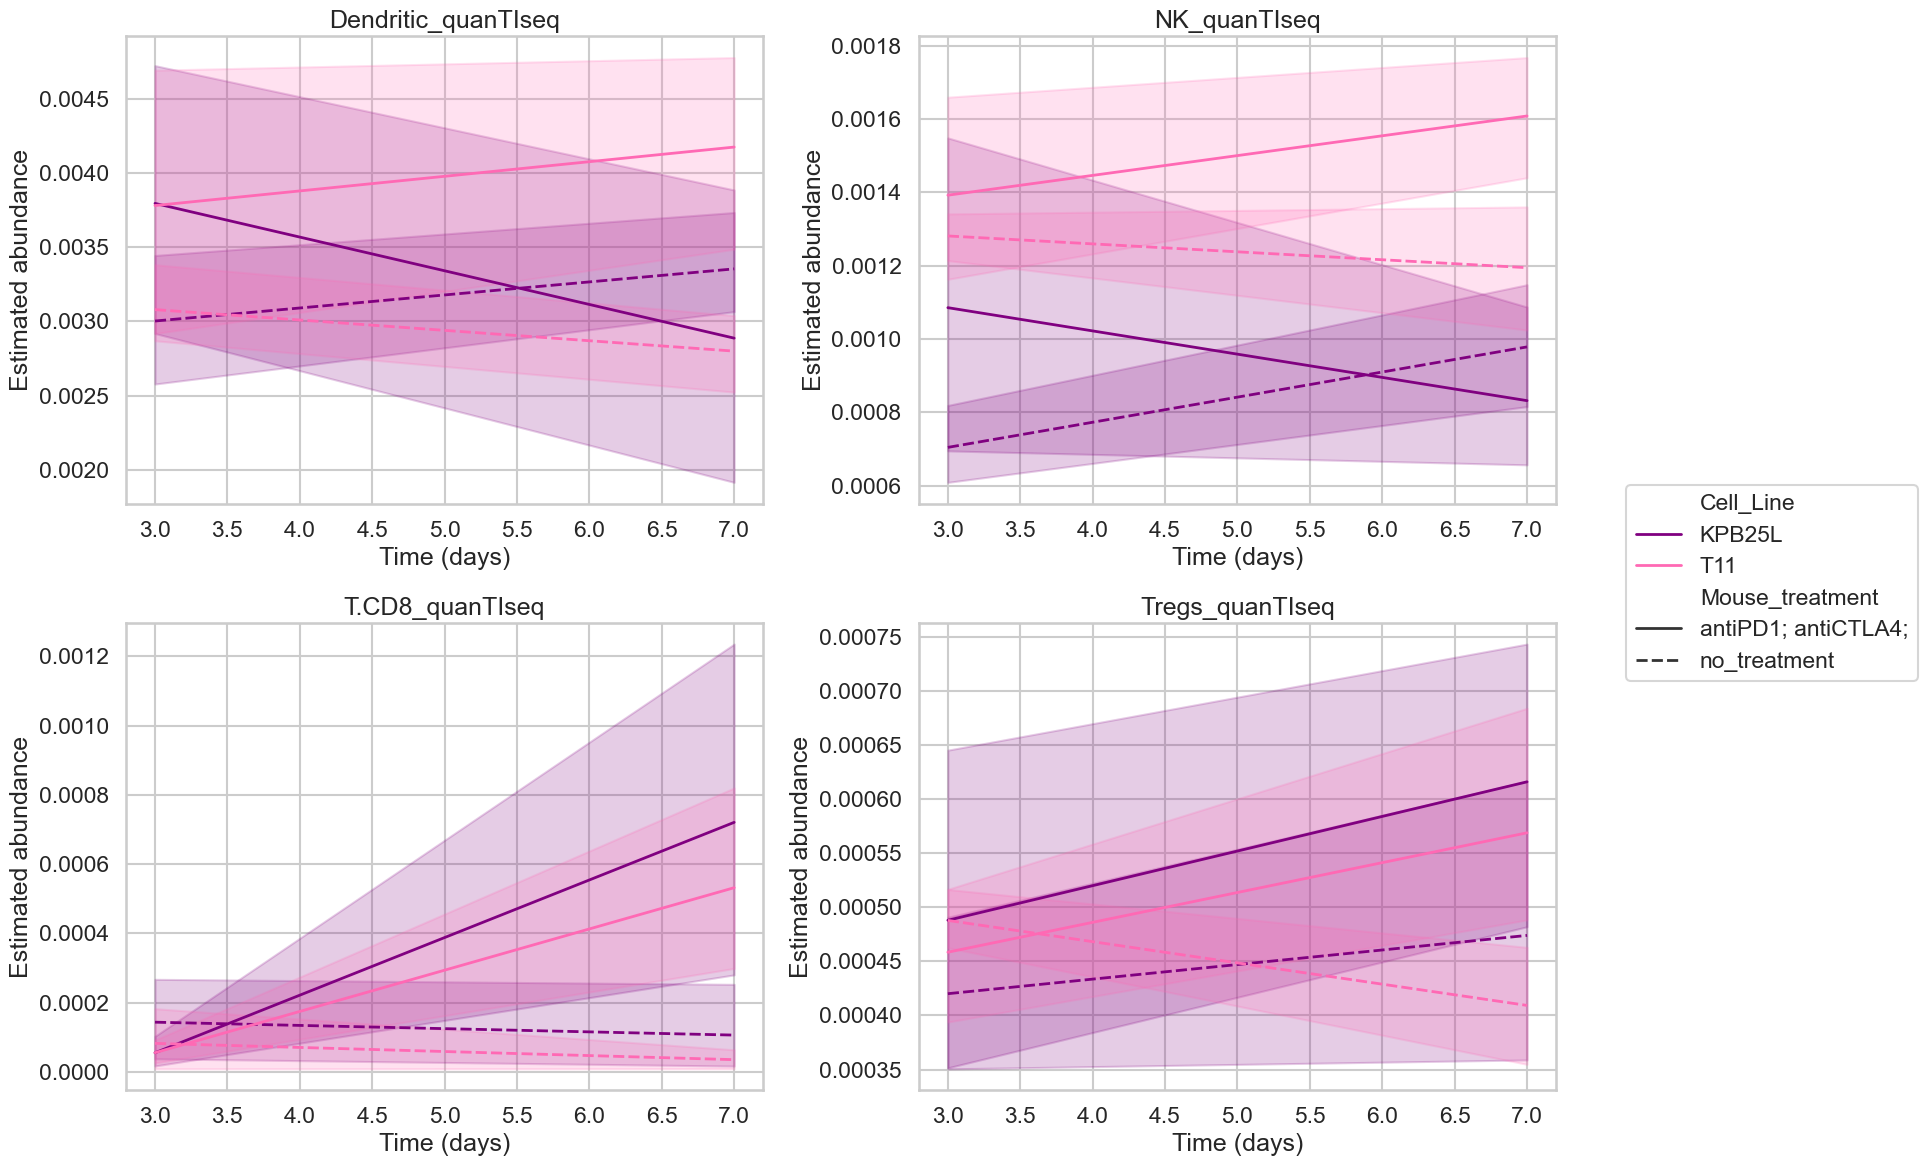

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert timepoints
time_map = {
    "Baseline": 0,
    "day3": 3,
    "day7": 7,
}

df_time["time_numeric"] = df_time["Timepoint"].map(time_map)
df_time = df_time.dropna(subset=["time_numeric"])

# Immune cell columns
immune_cols = [
    "Dendritic_quanTIseq",
    "NK_quanTIseq",
    "T.CD8_quanTIseq",
    "Tregs_quanTIseq"
]

# Custom colours for the two cell lines
palette = {
    "T11": "hotpink",
    "KPB25L": "purple"
}

sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, cell in enumerate(immune_cols):

    sns.lineplot(
        data=df_time,
        x="time_numeric",
        y=cell,
        hue="Cell_Line",            # colour = cell line
        palette=palette,            # <--- custom colours here
        style="Mouse_treatment",    # line style = treatment
        dashes=True,
        lw=2,
        ax=axes[i],
        legend=(i == 0)
    )

    axes[i].set_title(cell)
    axes[i].set_xlabel("Time (days)")
    axes[i].set_ylabel("Estimated abundance")

# Extract legend from first subplot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()

# Global legend
fig.legend(handles, labels,
           bbox_to_anchor=(1.02, 0.5),
           loc="center left")

plt.tight_layout()
fig.savefig("immune_infiltration_panels.pdf", bbox_inches="tight")
plt.show()


In [28]:
print(df["Mouse_treatment"].unique())
print(df["Timepoint"].unique())
print (df["Cell_Line"].unique())

<StringArray>
['antiPD1; antiCTLA4;', 'no_treatment']
Length: 2, dtype: str
<StringArray>
['day7', 'day3']
Length: 2, dtype: str
<StringArray>
['KPB25L', 'p53-2153F', 'p53-2225L', 'p53-2336R', 'p53-9263-3', 'T11']
Length: 6, dtype: str


In [31]:
not_df = df[(df['Cell_Line'] != 'T11') & (df['Cell_Line'] != 'KPB25L')]
not_df

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID,time_numeric
107,SRX5100645,0.000000,0.000301,0.000025,0.000029,no_treatment,day3,day3,NaN,GSM3554785,p53-2153F,"Mammary cancer, NOS",GSE124821,3.0
108,SRX5100721,0.000000,0.000209,0.000003,0.000109,no_treatment,day3,day3,NaN,GSM3554786,p53-2153F,"Mammary cancer, NOS",GSE124821,3.0
109,SRX5100644,0.000000,0.000193,0.000000,0.000139,no_treatment,day3,day3,NaN,GSM3554787,p53-2153F,"Mammary cancer, NOS",GSE124821,3.0
110,SRX5100757,0.000000,0.000250,0.000016,0.000243,no_treatment,day3,day3,NaN,GSM3554788,p53-2153F,"Mammary cancer, NOS",GSE124821,3.0
113,SRX5100756,0.000179,0.000263,0.000000,0.000170,no_treatment,day3,day3,Baseline,GSM3554791,p53-2225L,"Mammary cancer, NOS",GSE124821,3.0
114,SRX5100607,0.000539,0.000294,0.000000,0.000180,no_treatment,day3,day3,Baseline,GSM3554792,p53-2225L,"Mammary cancer, NOS",GSE124821,3.0
115,SRX5100606,0.000000,0.000271,0.000000,0.000094,no_treatment,day3,day3,Baseline,GSM3554793,p53-2225L,"Mammary cancer, NOS",GSE124821,3.0
116,SRX5100650,0.000541,0.000364,0.000000,0.000211,no_treatment,day3,day3,Baseline,GSM3554794,p53-2225L,"Mammary cancer, NOS",GSE124821,3.0
117,SRX5100701,0.000807,0.000347,0.000000,0.000234,no_treatment,day3,day3,Baseline,GSM3554795,p53-2225L,"Mammary cancer, NOS",GSE124821,3.0
118,SRX5100782,0.000943,0.000474,0.000000,0.000212,no_treatment,day3,day3,Baseline,GSM3554796,p53-2225L,"Mammary cancer, NOS",GSE124821,3.0


## Looking at the isotype treatment data 

In [43]:

df_iso = df[df['Mouse_treatment'].str.contains("isotype", case=False, na=False)]
df_iso

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
0,SRX3453162,0.000000,0.000879,0.000000,0.000000,isotype,NaN,NaN,Baseline,GSM2879407,EMT6,Mammary carcinoma,GSE107801
1,SRX3453163,0.002060,0.000940,0.000000,0.000406,isotype,NaN,NaN,Baseline,GSM2879408,EMT6,Mammary carcinoma,GSE107801
2,SRX3453164,0.001590,0.000739,0.000000,0.000352,isotype,NaN,NaN,Baseline,GSM2879409,EMT6,Mammary carcinoma,GSE107801
3,SRX3453165,0.000880,0.000558,0.000000,0.000304,isotype,NaN,NaN,Baseline,GSM2879410,EMT6,Mammary carcinoma,GSE107801
4,SRX3453166,0.001856,0.000691,0.000000,0.000313,isotype,NaN,NaN,Baseline,GSM2879411,EMT6,Mammary carcinoma,GSE107801
5,SRX3453167,0.002047,0.000925,0.000000,0.000409,isotype,NaN,NaN,Baseline,GSM2879412,EMT6,Mammary carcinoma,GSE107801
6,SRX3453168,0.001571,0.000967,0.000000,0.000406,isotype,NaN,NaN,Baseline,GSM2879413,EMT6,Mammary carcinoma,GSE107801
7,SRX3453169,0.001211,0.000406,0.000000,0.000274,isotype,NaN,NaN,Baseline,GSM2879414,EMT6,Mammary carcinoma,GSE107801
8,SRX3453170,0.001968,0.000849,0.000000,0.000369,isotype,NaN,NaN,Baseline,GSM2879415,EMT6,Mammary carcinoma,GSE107801
9,SRX3453171,0.001319,0.000734,0.000000,0.000308,isotype,NaN,NaN,Baseline,GSM2879416,EMT6,Mammary carcinoma,GSE107801


/var/folders/ls/j1nnm2jd3z5_pn315r5gyz9c0000gn/T/ipykernel_37090/4001848588.py:59: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(
/var/folders/ls/j1nnm2jd3z5_pn315r5gyz9c0000gn/T/ipykernel_37090/4001848588.py:59: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/var/folders/ls/j1nnm2jd3z5_pn315r5gyz9c0000gn/T/ipykernel_37090/4001848588.py:59: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/ls/j1nnm2jd3z5_pn315r5gyz9c0000gn/T/ipykernel_37090/4001848588.py:59: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.pointplot(


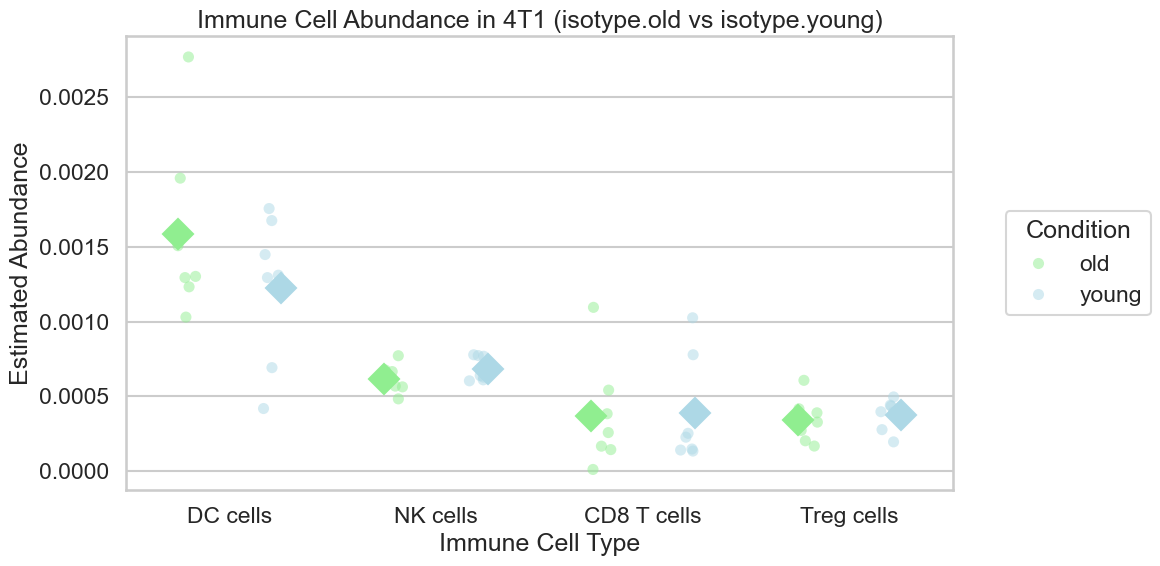

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 4T1 only
df_4T1 = df_iso[df_iso["Cell_Line"] == "4T1"].copy()

# Immune cell columns
immune_cols = [
    "Dendritic_quanTIseq",
    "NK_quanTIseq",
    "T.CD8_quanTIseq",
    "Tregs_quanTIseq"
]

# Rename for nicer x‑axis labels
label_map = {
    "Dendritic_quanTIseq": "DC cells",
    "NK_quanTIseq": "NK cells",
    "T.CD8_quanTIseq": "CD8 T cells",
    "Tregs_quanTIseq": "Treg cells"
}

# Melt into long format
df_long = df_4T1.melt(
    id_vars=["Condition"],
    value_vars=immune_cols,
    var_name="Immune_Cell",
    value_name="Abundance"
)

# Apply nicer labels
df_long["Immune_Cell"] = df_long["Immune_Cell"].map(label_map)

# Custom colours
palette = {
    "young": "lightblue",
    "old": "lightgreen"
}

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 6))

# Scatter points (individual mice) — slightly transparent
sns.stripplot(
    data=df_long,
    x="Immune_Cell",
    y="Abundance",
    hue="Condition",
    palette=palette,
    dodge=True,
    jitter=True,
    size=8,
    alpha=0.5        # <--- scatter transparency
)

# Mean points — fully opaque, diamond markers
sns.pointplot(
    data=df_long,
    x="Immune_Cell",
    y="Abundance",
    hue="Condition",
    palette=palette,
    dodge=0.5,
    join=False,
    markers="D",
    scale=1.5,
    errwidth=0,
    ci=None,
    alpha=1.0        # <--- mean fully opaque
)

plt.title("Immune Cell Abundance in 4T1 (isotype.old vs isotype.young)")
plt.xlabel("Immune Cell Type")
plt.ylabel("Estimated Abundance")

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Condition",
           bbox_to_anchor=(1.05, 0.5), loc="center left")

plt.tight_layout()
plt.show()


## Looking at the Responders vs Non-Responders data

In [10]:

df_time = df[df['Cell_Line'].isin(['T11', 'KPB25L'])]
df_ICI = df_time[df_time['Mouse_treatment']!='no_treatment']
df_ICI
df_ICI_R = df_ICI[df['ICB_study'] == 'R']
df_ICI_NR = df_ICI [df['ICB_study'] == 'NR']

/var/folders/ls/j1nnm2jd3z5_pn315r5gyz9c0000gn/T/ipykernel_38655/4205042535.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ICI_R = df_ICI[df['ICB_study'] == 'R']
/var/folders/ls/j1nnm2jd3z5_pn315r5gyz9c0000gn/T/ipykernel_38655/4205042535.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ICI_NR = df_ICI [df['ICB_study'] == 'NR']


In [11]:
df_ICI_R

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
48,SRX5100689,0.002064,0.000734,0.000382,0.000513,antiPD1; antiCTLA4;,day7,day7,R,GSM3554691,KPB25L,"Mammary cancer, NOS",GSE124821
53,SRX5100690,0.002253,0.000725,0.000024,0.000245,antiPD1; antiCTLA4;,day7,day7,R,GSM3554696,KPB25L,"Mammary cancer, NOS",GSE124821
54,SRX5100691,0.003449,0.000867,0.000003,0.000401,antiPD1; antiCTLA4;,day7,day7,R,GSM3554697,KPB25L,"Mammary cancer, NOS",GSE124821
55,SRX5100680,0.004349,0.000949,0.000017,0.000510,antiPD1; antiCTLA4;,day7,day7,R,GSM3554698,KPB25L,"Mammary cancer, NOS",GSE124821
63,SRX5100588,0.002501,0.000555,0.000000,0.000298,antiPD1; antiCTLA4;,day3,day3,R,GSM3554706,KPB25L,"Mammary cancer, NOS",GSE124821
64,SRX5100589,0.005952,0.001135,0.000178,0.000735,antiPD1; antiCTLA4;,day3,day3,R,GSM3554707,KPB25L,"Mammary cancer, NOS",GSE124821
65,SRX5100594,0.003723,0.000832,0.000000,0.000325,antiPD1; antiCTLA4;,day3,day3,R,GSM3554708,KPB25L,"Mammary cancer, NOS",GSE124821
66,SRX5100609,0.004967,0.002358,0.000100,0.000719,antiPD1; antiCTLA4;,day3,day3,R,GSM3554709,KPB25L,"Mammary cancer, NOS",GSE124821
67,SRX5100595,0.005011,0.001828,0.000127,0.000869,antiPD1; antiCTLA4;,day3,day3,R,GSM3554710,KPB25L,"Mammary cancer, NOS",GSE124821
72,SRX5100855,0.003358,0.000808,0.000000,0.000400,antiPD1; antiCTLA4;,end,end,R,GSM3554715,KPB25L,"Mammary cancer, NOS",GSE124821


In [12]:
df_ICI_NR

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
195,SRX5100624,0.003564,0.001534,0.000000,0.000486,antiPD1; antiCTLA4;,day7,day7,NR,GSM3554892,T11,"Mammary cancer, NOS",GSE124821
196,SRX5100625,0.002544,0.001137,0.000000,0.000382,antiPD1; antiCTLA4;,day7,day7,NR,GSM3554893,T11,"Mammary cancer, NOS",GSE124821
197,SRX5100626,0.003167,0.001506,0.000000,0.000535,antiPD1; antiCTLA4;,day7,day7,NR,GSM3554894,T11,"Mammary cancer, NOS",GSE124821
198,SRX5100627,0.003557,0.001515,0.000000,0.000546,antiPD1; antiCTLA4;,day7,day7,NR,GSM3554895,T11,"Mammary cancer, NOS",GSE124821
211,SRX5100849,0.001938,0.000985,0.000000,0.000324,antiPD1; antiCTLA4;,end,end,NR,GSM3554908,T11,"Mammary cancer, NOS",GSE124821
212,SRX5100846,0.003379,0.001496,0.000043,0.000507,antiPD1; antiCTLA4;,end,end,NR,GSM3554909,T11,"Mammary cancer, NOS",GSE124821
213,SRX5100847,0.002526,0.001164,0.000033,0.000388,antiPD1; antiCTLA4;,end,end,NR,GSM3554910,T11,"Mammary cancer, NOS",GSE124821
231,SRX5100759,0.003256,0.001332,0.000024,0.000592,antiPD1; antiCTLA4;,day3,day3,NR,GSM3554928,T11,"Mammary cancer, NOS",GSE124821
232,SRX5100810,0.002687,0.001110,0.000000,0.000426,antiPD1; antiCTLA4;,day3,day3,NR,GSM3554929,T11,"Mammary cancer, NOS",GSE124821
233,SRX5100809,0.004267,0.001544,0.000071,0.000513,antiPD1; antiCTLA4;,day3,day3,NR,GSM3554930,T11,"Mammary cancer, NOS",GSE124821


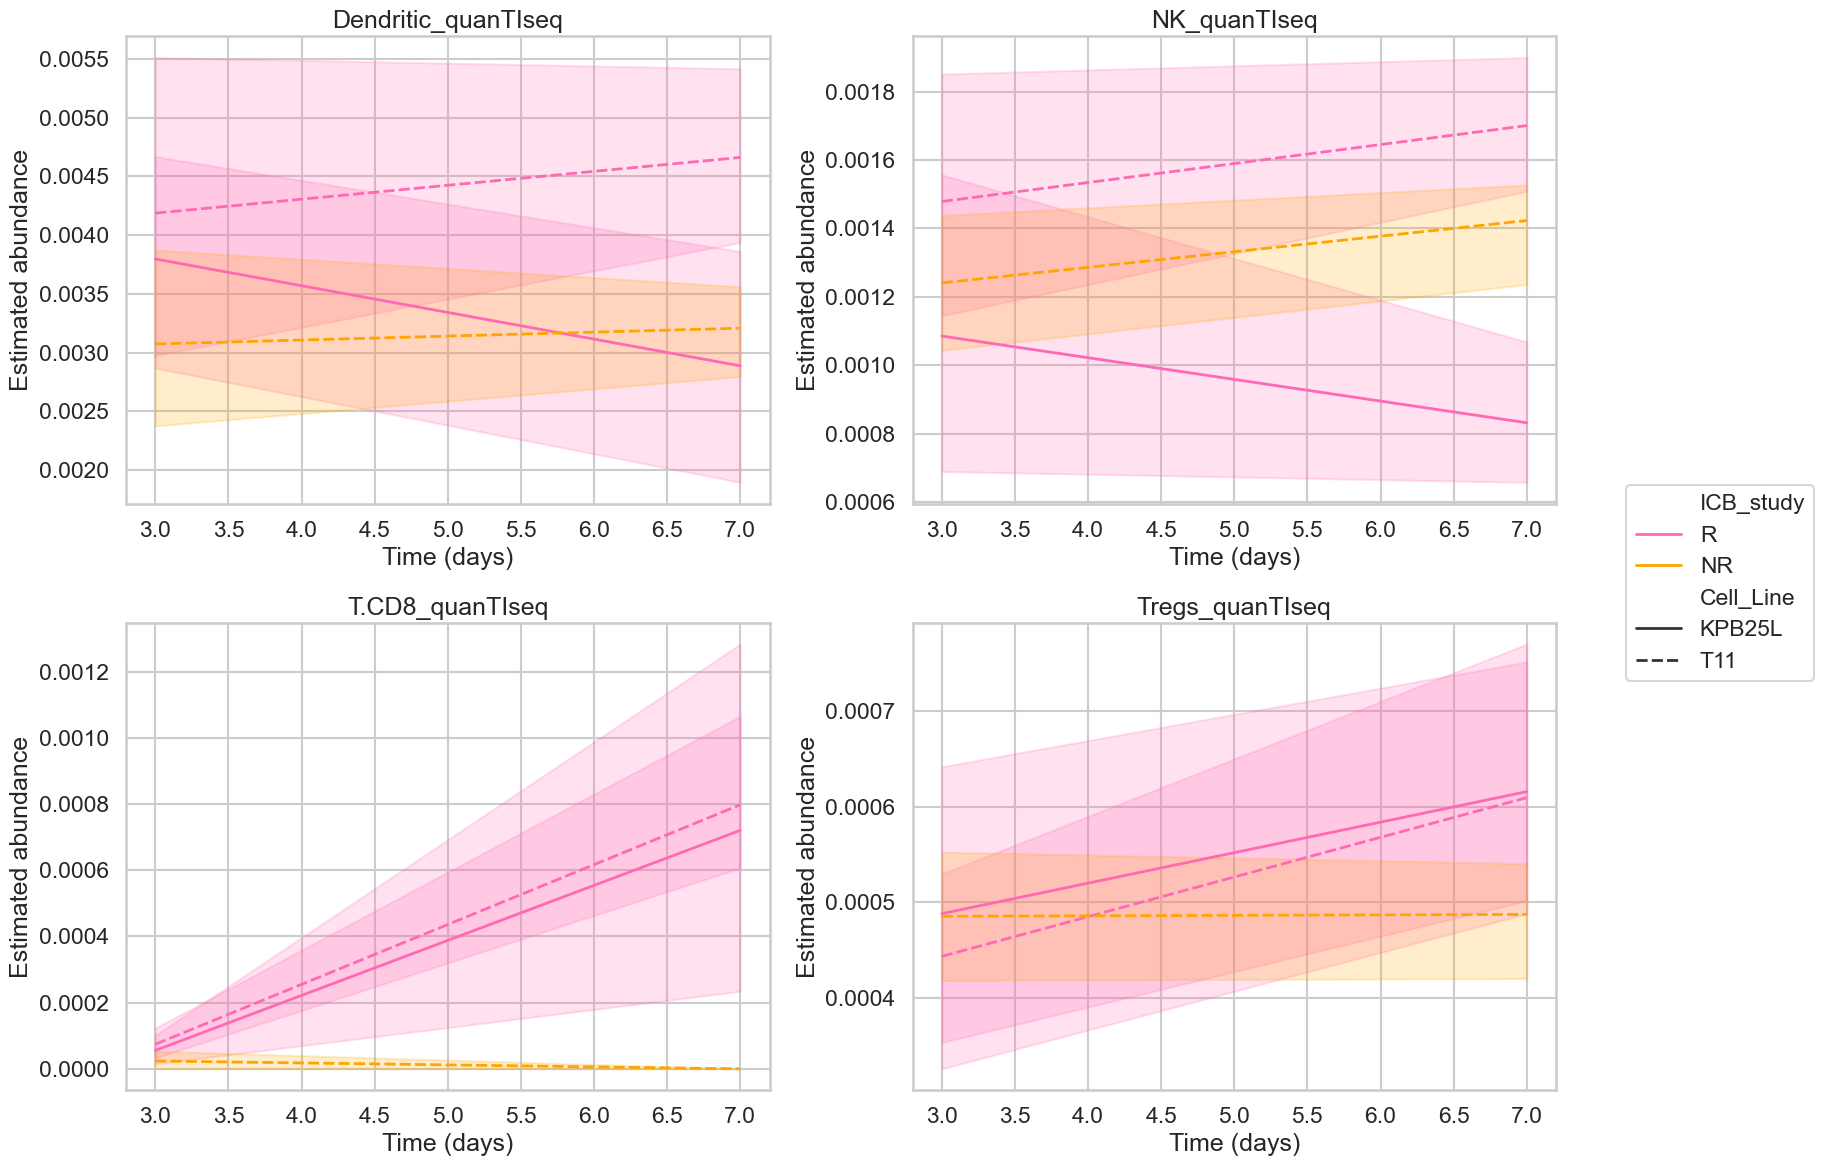

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert timepoints
time_map = {
    "Baseline": 0,
    "day3": 3,
    "day7": 7,
}

df_ICI["time_numeric"] = df_time["Timepoint"].map(time_map)
df_ICI = df_ICI.dropna(subset=["time_numeric"])

# Immune cell columns
immune_cols = [
    "Dendritic_quanTIseq",
    "NK_quanTIseq",
    "T.CD8_quanTIseq",
    "Tregs_quanTIseq"
]

# Custom colours for the two cell lines
palette = {
    "R": "hotpink",
    "NR": "orange"
}

sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, cell in enumerate(immune_cols):

    sns.lineplot(
        data=df_ICI,
        x="time_numeric",
        y=cell,
        hue="ICB_study",            # colour = responder or not
        palette=palette,            # <--- custom colours here
        style="Cell_Line",    # line style = cell line
        dashes=True,
        lw=2,
        ax=axes[i],
        legend=(i == 0)
    )

    axes[i].set_title(cell)
    axes[i].set_xlabel("Time (days)")
    axes[i].set_ylabel("Estimated abundance")

# Extract legend from first subplot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()

# Global legend
fig.legend(handles, labels,
           bbox_to_anchor=(1.02, 0.5),
           loc="center left")

plt.tight_layout()
fig.savefig("responders_nonresponders.pdf", bbox_inches="tight")
plt.show()


## TO DO : might also want to stratify by different pre-treatment so UV/Apobec/None - do 2 graphs for IC treated and non IC treated though 